In [6]:
import numpy as np

In [7]:
arr = np.array([1,2,3,4,5])

In [8]:
type(arr)

numpy.ndarray

In [12]:
arr.tolist()

[1, 2, 3, 4, 5]

In [23]:
matrix = np.array([[1,2,3], [4,5,6], [7,8,9], [10,11,12]])

In [24]:
type(matrix)

numpy.ndarray

In [25]:
matrix.shape

(4, 3)

In [27]:
matrix.size

12

In [29]:
matrix[0, 0].item()

1

In [31]:
aa = np.array([1, "a"])

In [32]:
aa[1]

np.str_('a')

In [33]:
aa[0]

np.str_('1')

In [35]:
matrix.shape

(4, 3)

In [36]:
type(matrix.shape)

tuple

In [37]:
행, 열 = matrix.shape

In [38]:
행

4

In [39]:
열

3

In [40]:
matrix.ndim

2

In [41]:
matrix.dtype

dtype('int64')

In [46]:
arr_zeros = np.zeros(5, dtype=int)

In [47]:
arr_zeros

array([0, 0, 0, 0, 0])

In [44]:
arr_zeros.dtype

dtype('float64')

In [45]:
[0] * 5

[0, 0, 0, 0, 0]

In [48]:
arr_onse = np.ones(5)
arr_onse

array([1., 1., 1., 1., 1.])

In [50]:
arr_full = np.full(5, 7)
arr_full

array([7, 7, 7, 7, 7])

In [52]:
p17 = arr_onse + arr_full
p17

array([8., 8., 8., 8., 8.])

In [53]:
p17 * arr_zeros

array([0., 0., 0., 0., 0.])

In [54]:
np.linspace(0, 10, 5)

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [60]:
np.linspace(0, 10, 6, dtype=int)

array([ 0,  1,  2,  4,  5,  7,  8, 10])

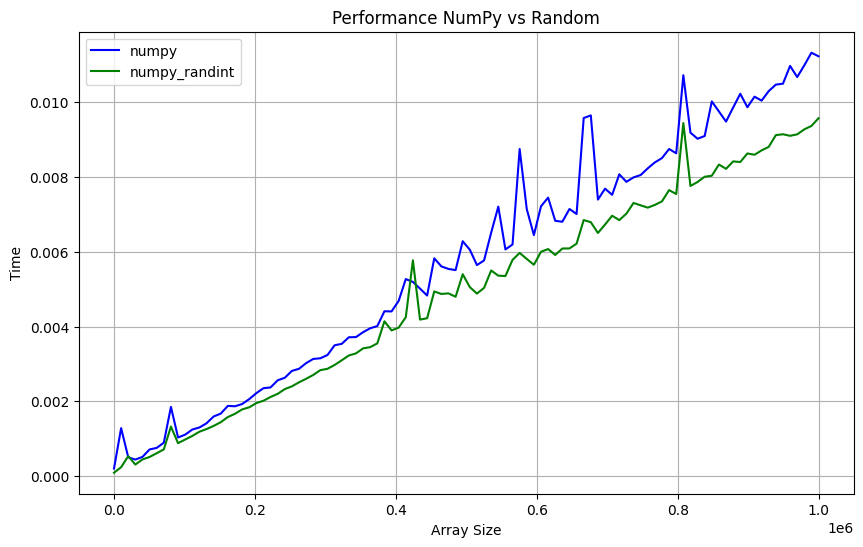

In [48]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import gc

# NumPy 기반 함수 randint
def gen_r_array_choices_numpy_randint(N):
    a = np.random.randint(0, 101, size=N)
    b = np.random.randint(0, 101, size=N)
    return a, b

# NumPy 기반 함수 choice
def gen_r_array_choices_numpy(N):
    a = np.random.choice(range(101), size=N)
    b = np.random.choice(range(101), size=N)
    return a, b

# Python random 기반 함수
def gen_r_array_choices(N):
    a = random.choices(range(101), k=N)
    b = random.choices(range(101), k=N)
    return a, b

# 고차 함수: 실행 시간 측정
def measure_time(func, N, runs=1):
    times = []
    for _ in range(runs):
        start = time.perf_counter()
        func(N)
        times.append(time.perf_counter() - start)
    return np.mean(times)

# 테스트할 N 값 생성 (1부터 1,000,000까지 100개 간격)
N_values = np.linspace(1, 1_000_000, 100, dtype=int)
# N_values = np.linspace(1, 1_000, 100, dtype=int)

# 각 함수의 실행 시간 저장용 리스트
numpy_times = []
numpy_times_randint = []
random_times = []

# 각 N 값 테스트 시간 측정값 배열에 저장
for N in N_values:
    # NumPy 함수 테스트
    nt = measure_time(gen_r_array_choices_numpy, N)
    numpy_times.append(nt)

    # NumPy 함수 테스트
    nt_ri = measure_time(gen_r_array_choices_numpy_randint, N)
    numpy_times_randint.append(nt_ri)

    # random 함수 테스트
    rt = measure_time(gen_r_array_choices, N)
    random_times.append(rt)

# 선그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(N_values, numpy_times, label='numpy', color='blue')
plt.plot(N_values, numpy_times_randint, label='numpy_randint', color='green')
# plt.plot(N_values, random_times, label='random', color='red')
plt.xlabel('Array Size')
plt.ylabel('Time')
plt.title('Performance NumPy vs Random')
plt.legend()
plt.grid(True)

plt.show()

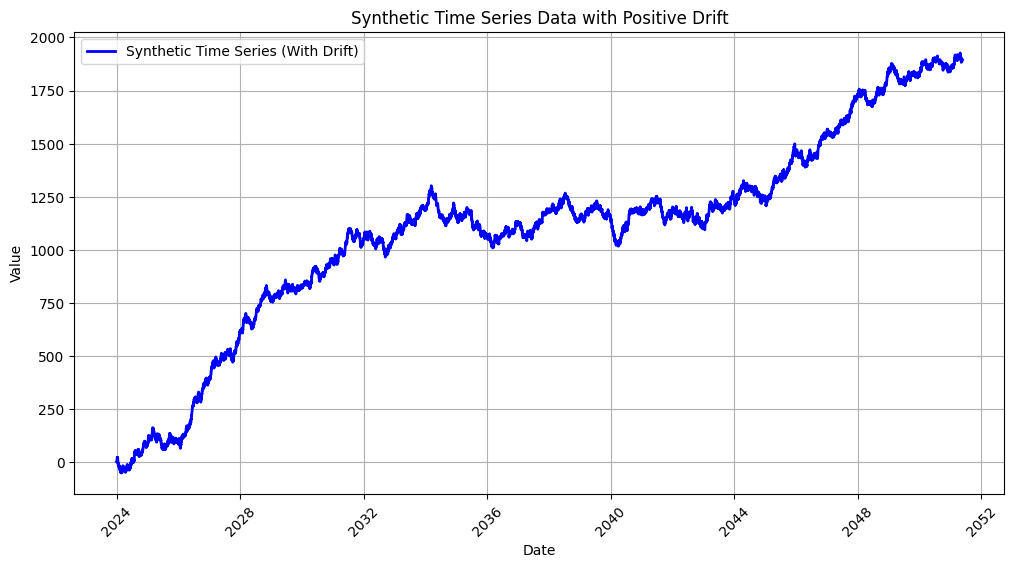

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 📌 1️⃣ 날짜 범위 생성 (2024년 1월부터 100일간)
dates = pd.date_range(start="2024-01-01", periods=10000, freq="D")

# 📌 2️⃣ 랜덤한 시계열 데이터 생성 (평균을 양수로 조정)
np.random.seed(42)  # 랜덤 시드 고정
drift = 0.2  # 데이터가 지속적으로 증가하도록 드리프트 추가
noise = np.random.randn(10000) * 5  # 랜덤 노이즈
time_series = np.cumsum(noise + drift)  # 누적합 적용

# 📌 3️⃣ 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(dates, time_series, label="Synthetic Time Series (With Drift)", color="blue", linewidth=2)

# 📌 4️⃣ 그래프 스타일 설정
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Synthetic Time Series Data with Positive Drift")
plt.legend()
plt.grid(True)

# 📌 5️⃣ 날짜 포맷 조정 (x축 라벨 간격 조정)
plt.xticks(rotation=45)
plt.show()


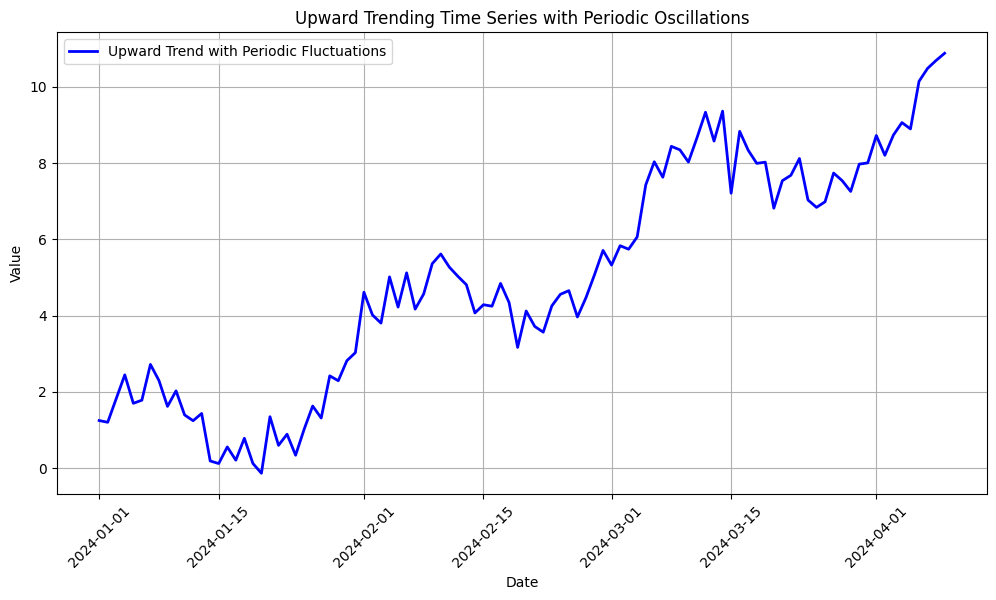

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 📌 1️⃣ 날짜 생성 (100일간)
dates = pd.date_range(start="2024-01-01", periods=100, freq="D")

# 📌 2️⃣ 기본적인 우상향 추세 (선형 증가)
trend = np.linspace(0, 10, 100)  # 0에서 10까지 선형 증가

# 📌 3️⃣ 사인과 코사인으로 주기적 패턴 추가
sin_wave = np.sin(np.linspace(0, 6 * np.pi, 100))  # 3번의 주기
cos_wave = np.cos(np.linspace(0, 6 * np.pi, 100))  # 코사인 패턴 추가

# 📌 4️⃣ 노이즈 추가 (변동성)
np.random.seed(42)  # 랜덤 시드 고정
noise = np.random.randn(100) * 0.5  # 작은 노이즈

# 📌 5️⃣ 최종 데이터 = 우상향 트렌드 + 주기적 변동 + 노이즈
time_series = trend + sin_wave + cos_wave + noise

# 📌 6️⃣ 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(dates, time_series, label="Upward Trend with Periodic Fluctuations", color="blue", linewidth=2)

# 📌 7️⃣ 그래프 스타일
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Upward Trending Time Series with Periodic Oscillations")
plt.legend()
plt.grid(True)

# 📌 8️⃣ x축 날짜 포맷 조정
plt.xticks(rotation=45)
plt.show()
